<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_11_Professor_Fundamentos_NLP_Resposta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 11 – Fundamentos de NLP

## Versão do Professor

### Curso
Deep Learning e Inteligência Artificial Generativa Aplicada

### Capacidades
- Desenvolver soluções com NLP.

### Conhecimentos
- Conceito de NLP.
- Pipeline de NLP.
- Estrutura textual.
- Manipulação de textos industriais.
- Tokenização.
- Normalização textual.
- Stopwords.
- Frequência de palavras.
- Interpretação de aplicações industriais.

### Estratégia
Introdução prática ao pipeline de NLP utilizando textos industriais.

### Recursos
- Python.
- NLTK.
- Google Colab.
- Dataset textual industrial.

### Evidência de aprendizagem
Pipeline básico de NLP implementado em notebook.

# 1. Contextualização da aula

NLP significa **Natural Language Processing**, ou **Processamento de Linguagem Natural**.

É uma área da Inteligência Artificial que permite que sistemas computacionais processem, analisem e interpretem textos escritos em linguagem humana.

Na indústria, NLP pode ser aplicado em:

- análise de chamados técnicos;
- classificação de relatos de manutenção;
- interpretação de ordens de serviço;
- análise de não conformidades;
- triagem automática de ocorrências;
- identificação de padrões em relatórios operacionais;
- apoio à tomada de decisão gerencial.

Nesta aula, trabalharemos com pequenos relatos industriais fictícios para compreender o fluxo inicial de um pipeline de NLP.

# 2. O que é um pipeline de NLP?

Um pipeline de NLP é uma sequência de etapas para transformar texto bruto em informação útil.

Exemplo de pipeline básico:

```text
Texto bruto
→ limpeza
→ normalização
→ tokenização
→ remoção de stopwords
→ análise de frequência
→ interpretação
```

Em projetos mais avançados, esse pipeline pode evoluir para:

```text
Texto bruto
→ pré-processamento
→ vetorização
→ treinamento de modelo
→ avaliação
→ implantação
```

Nesta aula, vamos focar na primeira parte: entender, limpar, separar e analisar textos.

# 3. Estrutura textual

Um texto pode ser analisado em diferentes níveis:

## Documento
Um texto completo, como um relatório de manutenção.

## Frase
Uma unidade de sentido dentro do documento.

## Palavra ou token
Unidade básica usada para análise computacional.

## Caracteres
Letras, números, pontuações e símbolos.

Exemplo:

```text
"Motor apresentou aquecimento acima do normal."
```

Pode ser dividido em tokens:

```text
["motor", "apresentou", "aquecimento", "acima", "do", "normal"]
```

In [ ]:
# Célula 1 - Instalação e importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from collections import Counter

import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

print("Bibliotecas importadas com sucesso!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Bibliotecas importadas com sucesso!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 4. Carregamento do dataset

O dataset contém relatos industriais fictícios com as seguintes colunas:

- `id`: identificação do relato;
- `setor`: setor de origem;
- `tipo_relato`: classificação manual do relato;
- `texto`: descrição textual da ocorrência.

Esse tipo de base pode representar chamados técnicos, ordens de serviço, registros de manutenção ou apontamentos de qualidade.

In [ ]:
# Célula 2 - Carregamento do dataset

caminho_dataset = "/content/drive/MyDrive/Classroom/Deep Learning e Inteligência Artificial Generativa Aplicada/dataset_aula11_nlp_relatos_industriais.csv"

# Caminho alternativo para execução neste ambiente
try:
    df = pd.read_csv(caminho_dataset)
except FileNotFoundError:
    df = pd.read_csv("/mnt/data/dataset_aula11_nlp_relatos_industriais.csv")

df.head()

,id,setor,tipo_relato,texto
0,1,Manutenção,falha,Motor da esteira apresentou aquecimento acima ...
1,2,Produção,normal,Linha de montagem operou sem interrupções e de...
2,3,Qualidade,defeito,Foram identificadas peças com rebarbas e acaba...
3,4,Manutenção,falha,Sensor de presença não realizou a leitura corr...
4,5,Produção,alerta,Tempo de ciclo aumentou após troca do lote de ...


In [ ]:
# Célula 3 - Informações gerais do dataset

print("Quantidade de registros:", len(df))
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
print(df.dtypes)

print("\nQuantidade por setor:")
print(df["setor"].value_counts())

print("\nQuantidade por tipo de relato:")
print(df["tipo_relato"].value_counts())

Quantidade de registros: 24

Colunas:
['id', 'setor', 'tipo_relato', 'texto']

Tipos de dados:
id              int64
setor          object
tipo_relato    object
texto          object
dtype: object

Quantidade por setor:
setor
Manutenção    8
Produção      8
Qualidade     8
Name: count, dtype: int64

Quantidade por tipo de relato:
tipo_relato
falha      7
normal     6
alerta     6
defeito    5
Name: count, dtype: int64


# 5. Visualização da distribuição dos relatos

Antes de processar os textos, é importante entender a base.

Vamos visualizar a quantidade de registros por setor e por tipo de relato.

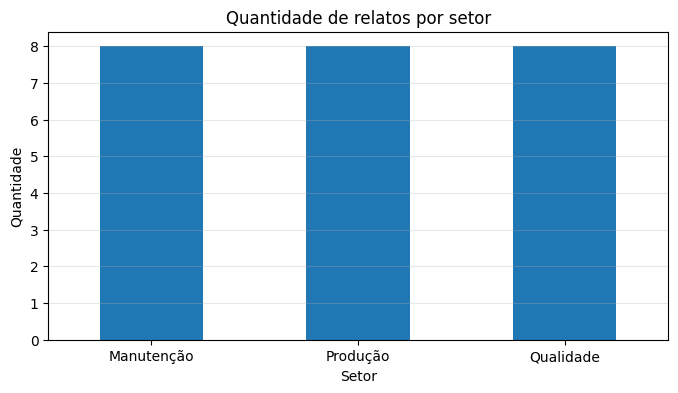

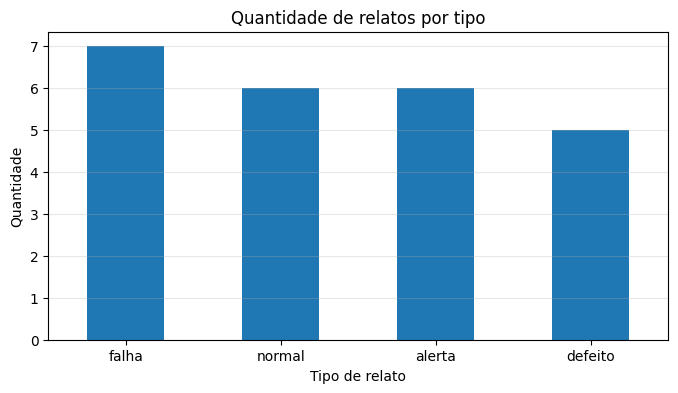

In [ ]:
# Célula 4 - Gráficos de distribuição

plt.figure(figsize=(8, 4))
df["setor"].value_counts().plot(kind="bar")
plt.title("Quantidade de relatos por setor")
plt.xlabel("Setor")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
df["tipo_relato"].value_counts().plot(kind="bar")
plt.title("Quantidade de relatos por tipo")
plt.xlabel("Tipo de relato")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

# 6. Análise de um texto individual

Vamos selecionar um relato e observar sua estrutura.

O computador enxerga o texto como uma sequência de caracteres. Para transformar esse texto em informação útil, precisamos aplicar etapas de pré-processamento.

In [ ]:
# Célula 5 - Selecionando um texto

texto_exemplo = df.loc[0, "texto"]

print("Texto original:")
print(texto_exemplo)

print("\nQuantidade de caracteres:", len(texto_exemplo))
print("Quantidade de palavras usando split simples:", len(texto_exemplo.split()))

Texto original:
Motor da esteira apresentou aquecimento acima do normal durante o segundo turno.

Quantidade de caracteres: 80
Quantidade de palavras usando split simples: 12


# 7. Normalização textual

A normalização deixa os textos em um formato mais padronizado.

Etapas comuns:

- converter para letras minúsculas;
- remover pontuação;
- remover números, quando não forem importantes;
- remover espaços extras;
- tratar acentuação, quando necessário.

Nesta aula, manteremos os acentos, pois eles não impedem a análise básica.

In [ ]:
# Célula 6 - Função de limpeza textual

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)
    texto = texto.translate(str.maketrans("", "", string.punctuation))
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

texto_limpo = limpar_texto(texto_exemplo)

print("Texto original:")
print(texto_exemplo)

print("\nTexto limpo:")
print(texto_limpo)

Texto original:
Motor da esteira apresentou aquecimento acima do normal durante o segundo turno.

Texto limpo:
motor da esteira apresentou aquecimento acima do normal durante o segundo turno


# 8. Tokenização

Tokenização é o processo de dividir o texto em unidades menores chamadas **tokens**.

Na maioria das análises iniciais, os tokens são palavras.

Exemplo:

```text
"motor apresentou falha"
```

Tokens:

```text
["motor", "apresentou", "falha"]
```

In [ ]:
# Célula 7 - Tokenização

tokens = word_tokenize(texto_limpo, language="portuguese")

print(tokens)
print("\nQuantidade de tokens:", len(tokens))

['motor', 'da', 'esteira', 'apresentou', 'aquecimento', 'acima', 'do', 'normal', 'durante', 'o', 'segundo', 'turno']

Quantidade de tokens: 12


# 9. Stopwords

Stopwords são palavras muito frequentes que geralmente carregam pouco significado isoladamente.

Exemplos:

- de;
- a;
- o;
- e;
- do;
- da;
- em;
- para.

Remover stopwords pode ajudar a destacar palavras mais importantes do texto.

In [ ]:
# Célula 8 - Remoção de stopwords

stopwords_pt = set(stopwords.words("portuguese"))

tokens_sem_stopwords = [token for token in tokens if token not in stopwords_pt]

print("Tokens originais:")
print(tokens)

print("\nTokens sem stopwords:")
print(tokens_sem_stopwords)

Tokens originais:
['motor', 'da', 'esteira', 'apresentou', 'aquecimento', 'acima', 'do', 'normal', 'durante', 'o', 'segundo', 'turno']

Tokens sem stopwords:
['motor', 'esteira', 'apresentou', 'aquecimento', 'acima', 'normal', 'durante', 'segundo', 'turno']


# 10. Aplicando o pipeline ao dataset completo

Agora vamos aplicar as etapas anteriores em todos os relatos:

1. limpeza;
2. tokenização;
3. remoção de stopwords.

Criaremos novas colunas no DataFrame.

In [ ]:
# Célula 9 - Pipeline básico de NLP

def pipeline_nlp_basico(texto):
    texto_limpo = limpar_texto(texto)
    tokens = word_tokenize(texto_limpo, language="portuguese")
    tokens_sem_stop = [token for token in tokens if token not in stopwords_pt]
    return texto_limpo, tokens, tokens_sem_stop

df["texto_limpo"], df["tokens"], df["tokens_sem_stopwords"] = zip(*df["texto"].apply(pipeline_nlp_basico))

df[["texto", "texto_limpo", "tokens_sem_stopwords"]].head()

,texto,texto_limpo,tokens_sem_stopwords
0,Motor da esteira apresentou aquecimento acima ...,motor da esteira apresentou aquecimento acima ...,"[motor, esteira, apresentou, aquecimento, acim..."
1,Linha de montagem operou sem interrupções e de...,linha de montagem operou sem interrupções e de...,"[linha, montagem, operou, interrupções, dentro..."
2,Foram identificadas peças com rebarbas e acaba...,foram identificadas peças com rebarbas e acaba...,"[identificadas, peças, rebarbas, acabamento, i..."
3,Sensor de presença não realizou a leitura corr...,sensor de presença não realizou a leitura corr...,"[sensor, presença, realizou, leitura, correta,..."
4,Tempo de ciclo aumentou após troca do lote de ...,tempo de ciclo aumentou após troca do lote de ...,"[tempo, ciclo, aumentou, após, troca, lote, ma..."


# 11. Contagem de palavras

A contagem de palavras permite identificar termos recorrentes.

Em textos industriais, palavras frequentes podem indicar:

- falhas recorrentes;
- componentes críticos;
- setores com maior ocorrência;
- problemas de processo;
- padrões de manutenção.

In [ ]:
# Célula 10 - Frequência geral de palavras

todos_tokens = []

for lista_tokens in df["tokens_sem_stopwords"]:
    todos_tokens.extend(lista_tokens)

frequencia = Counter(todos_tokens)

frequencia_mais_comum = frequencia.most_common(15)

print("Palavras mais frequentes:")
for palavra, qtd in frequencia_mais_comum:
    print(f"{palavra}: {qtd}")

Palavras mais frequentes:
esteira: 3
apresentou: 3
peças: 3
lote: 3
motor: 2
durante: 2
linha: 2
montagem: 2
tempo: 2
ciclo: 2
após: 2
sensor: 2
aumentou: 2
inspeção: 2
ferramentas: 2


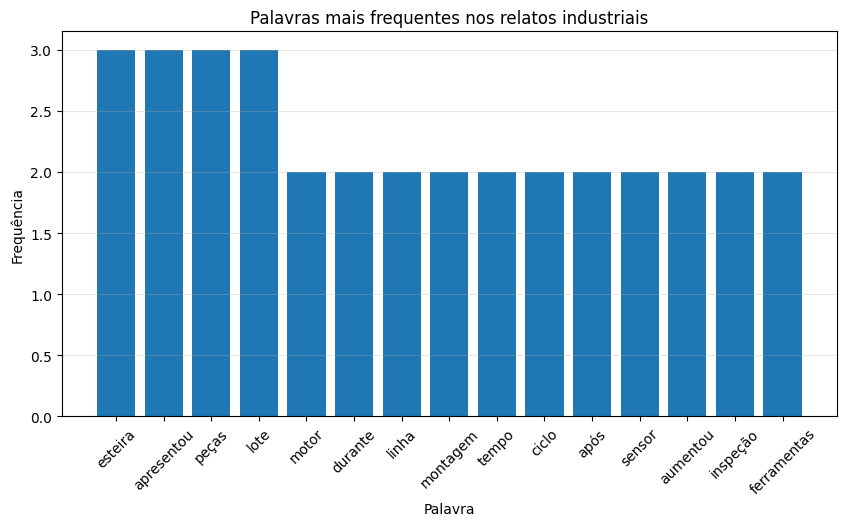

In [ ]:
# Célula 11 - Gráfico das palavras mais frequentes

palavras = [item[0] for item in frequencia_mais_comum]
quantidades = [item[1] for item in frequencia_mais_comum]

plt.figure(figsize=(10, 5))
plt.bar(palavras, quantidades)
plt.title("Palavras mais frequentes nos relatos industriais")
plt.xlabel("Palavra")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# 12. Análise por tipo de relato

Agora vamos verificar quais palavras aparecem com mais frequência em cada tipo de relato.

Isso pode ajudar a entender padrões de linguagem associados a:

- falhas;
- alertas;
- defeitos;
- situações normais.

In [ ]:
# Célula 12 - Frequência de palavras por tipo de relato

def palavras_mais_frequentes_por_tipo(tipo, n=10):
    tokens_tipo = []
    subset = df[df["tipo_relato"] == tipo]

    for lista_tokens in subset["tokens_sem_stopwords"]:
        tokens_tipo.extend(lista_tokens)

    return Counter(tokens_tipo).most_common(n)

for tipo in sorted(df["tipo_relato"].unique()):
    print(f"\nTipo de relato: {tipo}")
    for palavra, qtd in palavras_mais_frequentes_por_tipo(tipo):
        print(f"{palavra}: {qtd}")


Tipo de relato: alerta
aumentou: 2
lote: 2
ficou: 2
tempo: 1
ciclo: 1
após: 1
troca: 1
matériaprima: 1
operador: 1
relatou: 1

Tipo de relato: defeito
peças: 2
apresentou: 2
identificadas: 1
rebarbas: 1
acabamento: 1
irregular: 1
após: 1
usinagem: 1
peça: 1
trinca: 1

Tipo de relato: falha
motor: 2
esteira: 2
sensor: 2
registrou: 2
apresentou: 1
aquecimento: 1
acima: 1
normal: 1
durante: 1
segundo: 1

Tipo de relato: normal
linha: 1
montagem: 1
operou: 1
interrupções: 1
dentro: 1
tempo: 1
ciclo: 1
previsto: 1
inspeção: 1
visual: 1


# 13. Tamanho dos relatos

O tamanho dos relatos pode ser uma variável útil.

Relatos muito curtos podem ter pouca informação.

Relatos muito longos podem conter detalhes técnicos importantes.

Vamos calcular:

- quantidade de caracteres;
- quantidade de tokens;
- quantidade de tokens sem stopwords.

In [ ]:
# Célula 13 - Tamanho dos relatos

df["qtd_caracteres"] = df["texto"].apply(len)
df["qtd_tokens"] = df["tokens"].apply(len)
df["qtd_tokens_sem_stopwords"] = df["tokens_sem_stopwords"].apply(len)

df[["texto", "qtd_caracteres", "qtd_tokens", "qtd_tokens_sem_stopwords"]].head()

,texto,qtd_caracteres,qtd_tokens,qtd_tokens_sem_stopwords
0,Motor da esteira apresentou aquecimento acima ...,80,12,9
1,Linha de montagem operou sem interrupções e de...,78,13,8
2,Foram identificadas peças com rebarbas e acaba...,78,11,7
3,Sensor de presença não realizou a leitura corr...,82,13,8
4,Tempo de ciclo aumentou após troca do lote de ...,60,10,7


<Figure size 800x500 with 0 Axes>

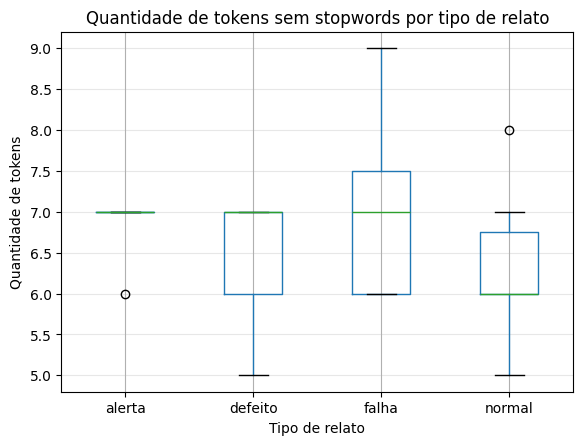

In [ ]:
# Célula 14 - Gráfico de tamanho dos relatos por tipo

plt.figure(figsize=(8, 5))
df.boxplot(column="qtd_tokens_sem_stopwords", by="tipo_relato")
plt.title("Quantidade de tokens sem stopwords por tipo de relato")
plt.suptitle("")
plt.xlabel("Tipo de relato")
plt.ylabel("Quantidade de tokens")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 14. Busca simples por palavras-chave

Uma aplicação básica de NLP é localizar relatos que contenham determinadas palavras.

Exemplos industriais:

- buscar todos os relatos com a palavra `sensor`;
- buscar todos os relatos com `motor`;
- buscar ocorrências de `temperatura`;
- buscar problemas associados a `falha`.

In [ ]:
# Célula 15 - Busca por palavra-chave

palavra_chave = "sensor"

df_busca = df[df["texto_limpo"].str.contains(palavra_chave)]

print(f"Relatos encontrados com a palavra '{palavra_chave}':")
display(df_busca[["id", "setor", "tipo_relato", "texto"]])

Relatos encontrados com a palavra 'sensor':


,id,setor,tipo_relato,texto
3,4,Manutenção,falha,Sensor de presença não realizou a leitura corr...
19,20,Produção,falha,Esteira parou por falha no sensor de fim de cu...
21,22,Manutenção,normal,Teste funcional dos sensores foi concluído sem...


# 15. Construção de uma função de análise simples

Agora vamos criar uma função para receber um novo relato industrial e aplicar o mesmo pipeline.

Essa função poderá ser usada para analisar textos digitados pelo usuário.

In [ ]:
# Célula 16 - Função para analisar novo relato

def analisar_relato(texto):
    texto_limpo = limpar_texto(texto)
    tokens = word_tokenize(texto_limpo, language="portuguese")
    tokens_sem_stop = [token for token in tokens if token not in stopwords_pt]

    resultado = {
        "texto_original": texto,
        "texto_limpo": texto_limpo,
        "tokens": tokens,
        "tokens_sem_stopwords": tokens_sem_stop,
        "qtd_tokens": len(tokens),
        "qtd_tokens_sem_stopwords": len(tokens_sem_stop)
    }

    return resultado

novo_relato = "Motor apresentou vibração elevada e aquecimento durante a operação."

analise = analisar_relato(novo_relato)

for chave, valor in analise.items():
    print(f"{chave}: {valor}")

texto_original: Motor apresentou vibração elevada e aquecimento durante a operação.
texto_limpo: motor apresentou vibração elevada e aquecimento durante a operação
tokens: ['motor', 'apresentou', 'vibração', 'elevada', 'e', 'aquecimento', 'durante', 'a', 'operação']
tokens_sem_stopwords: ['motor', 'apresentou', 'vibração', 'elevada', 'aquecimento', 'durante', 'operação']
qtd_tokens: 9
qtd_tokens_sem_stopwords: 7


# 16. Interpretação industrial

A partir do pipeline básico, já conseguimos:

- limpar relatos industriais;
- separar palavras relevantes;
- remover palavras pouco informativas;
- identificar termos recorrentes;
- buscar palavras-chave;
- analisar padrões por tipo de relato.

Em aulas posteriores, esse pipeline poderá evoluir para:

- vetorização;
- classificação automática de chamados;
- análise de sentimentos;
- extração de informações;
- uso de embeddings;
- uso de modelos Transformers.

# 17. Atividade avaliativa

## Proposta

O aluno deverá entregar um notebook contendo:

1. Carregamento do dataset;
2. Visualização dos registros;
3. Limpeza textual;
4. Tokenização;
5. Remoção de stopwords;
6. Frequência de palavras;
7. Análise por tipo de relato;
8. Busca por palavra-chave;
9. Função para analisar novo relato;
10. Interpretação técnica dos resultados.

## Questões para relatório

1. O que é NLP?

O NLP (Natural Language Processing) é um subcampo da Inteligência Artificial responsável pelo processamento computacional da linguagem natural.
Ele utiliza técnicas de aprendizado de máquina, estatística e linguística para analisar, compreender e gerar texto ou fala humana.
Permite a conversão de linguagem não estruturada em representações formais processáveis por algoritmos.
Inclui tarefas como tokenização, classificação de texto, tradução automática e análise de sentimentos.
Assim, o NLP viabiliza a interação eficiente entre humanos e sistemas computacionais por meio da linguagem.

2. O que é um pipeline de NLP?

Um pipeline de NLP é uma sequência estruturada de etapas que processam textos desde a entrada bruta até a geração de resultados úteis.
Ele organiza o fluxo de transformação da linguagem natural em dados interpretáveis por máquinas.
Normalmente inclui etapas como pré-processamento, tokenização, remoção de ruído e normalização.
Também pode envolver extração de características e aplicação de modelos de aprendizado de máquina.
Cada etapa prepara os dados para a próxima fase do processamento.
Assim, o pipeline garante um processamento eficiente, padronizado e escalável de tarefas de NLP.

3. O que é tokenização?

A tokenização é o processo de dividir um texto em unidades menores chamadas tokens.
Esses tokens podem ser palavras, caracteres ou subpalavras, dependendo da abordagem utilizada.
É uma das primeiras etapas do processamento de linguagem natural.
Permite transformar texto bruto em uma estrutura que pode ser analisada por algoritmos.
Por exemplo, a frase “Eu gosto de IA” pode ser dividida em ["Eu", "gosto", "de", "IA"].
A tokenização facilita tarefas como análise de texto e modelagem de linguagem.
Assim, é essencial para preparar dados textuais para modelos de NLP.

4. O que são stopwords?

As stopwords são palavras muito comuns em um idioma que geralmente não agregam significado relevante para a análise de texto.
Exemplos incluem “de”, “a”, “o”, “e”, “em”, entre outras.
Elas aparecem com alta frequência, mas possuem baixo valor informativo.
Durante o pré-processamento em NLP, essas palavras costumam ser removidas.
Isso reduz o volume de dados e melhora o desempenho dos modelos.
A remoção de stopwords ajuda a focar nas palavras mais importantes do texto.
Assim, contribui para uma análise mais eficiente e precisa.

5. Quais palavras mais apareceram no dataset?

As palavras mais frequentes no dataset foram “esteira”, “apresentou”, “peças” e “lote”, com maior número de ocorrências. Também se destacam termos como “motor”, “linha”, “montagem” e “sensor”, indicando um contexto voltado a processos industriais e produção.

6. Quais termos podem indicar falha ou defeito?
Os termos que indicam falha ou defeito incluem “apresentou”, “aumentou”, “inspeção”, “sensor” e “motor”, pois estão associados a ocorrências anormais, identificação de problemas ou componentes críticos no processo industrial.

7. Como NLP pode apoiar a manutenção industrial?

O NLP pode apoiar a manutenção industrial ao analisar automaticamente textos de relatórios, logs e históricos de falhas.
Ele permite identificar padrões e palavras associadas a defeitos e anomalias.
Pode ser utilizado para classificar ocorrências (falha elétrica, mecânica, sensor, etc.).
Também auxilia na detecção precoce de problemas por meio da análise de histórico textual.
O NLP possibilita a extração de informações relevantes de grandes volumes de dados não estruturados.
Além disso, pode apoiar sistemas de manutenção preditiva e tomada de decisão.
Assim, contribui para reduzir paradas, custos e aumentar a confiabilidade dos equipamentos.

8. Como NLP pode apoiar o controle de qualidade?

O NLP pode apoiar o controle de qualidade ao analisar automaticamente registros, relatórios e descrições de defeitos.
Ele permite identificar padrões de problemas recorrentes nos processos produtivos.
Pode ser utilizado para classificar não conformidades e tipos de defeitos.
Também auxilia na detecção de anomalias em textos de inspeção e produção.
O NLP possibilita a extração de informações relevantes de dados não estruturados.
Além disso, contribui para a padronização de registros e redução de erros humanos.
Assim, melhora a tomada de decisão e aumenta a qualidade e consistência dos produtos.
Forneça seus comentários sobre o BizChat

9. Quais limitações existem em uma análise baseada apenas em frequência de palavras?



## Critérios de avaliação

O aluno será avaliado se:

- identifica etapas do pipeline NLP;
- manipula corretamente dados textuais;
- aplica limpeza, tokenização e remoção de stopwords;
- interpreta aplicações industriais;
- organiza adequadamente o notebook.